# Algoritmos No Supervisados

**Objetivo:** Introducir los conceptos fundamentales y la aplicación práctica de algoritmos de aprendizaje no supervisado utilizando Python y bibliotecas populares como Scikit-learn, Pandas y NumPy.

**Temas Cubiertos:**
1.  Clustering (Agrupamiento)
    *   K-Means
    *   Aglomerativo Jerárquico
    *   DBSCAN
2.  Reducción de la Dimensionalidad
    *   Análisis de Componentes Principales (PCA)
    *   t-SNE (para visualización)
3.  Ejercicio Práctico: Clustering aplicado a Churn

## 0. Configuración Inicial

Primero, importaremos las bibliotecas necesarias para nuestro análisis.
*   **Pandas:** Para manipulación y análisis de datos (especialmente DataFrames).
*   **NumPy:** Para operaciones numéricas eficientes, especialmente con arrays.
*   **Scikit-learn:** La biblioteca principal para machine learning en Python, que usaremos para clustering y reducción de dimensionalidad.
*   **Matplotlib & Seaborn:** Para visualización de datos.
*   **SciPy:** La usaremos específicamente para el dendrograma en clustering jerárquico.

In [53]:
# Importación de librerías
import pandas as pd
import numpy as np

# Para Clustering y Reducción de Dimensionalidad
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Para escalar datos numéricos y codificar categóricos si fuera necesario
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score # Para evaluar clusters

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para clustering jerárquico y dendrogramas
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuraciones adicionales para visualización
%matplotlib inline
sns.set(style="whitegrid")

## 1. Clustering (Agrupamiento)

El clustering es una técnica de aprendizaje no supervisado cuyo objetivo es encontrar grupos (clusters) naturales en los datos, de modo que los puntos dentro de un mismo grupo sean más similares entre sí que con los puntos de otros grupos. No tenemos etiquetas predefinidas; el algoritmo las descubre.

### 1.1. K-Means (No Jerárquico)

**Concepto:**
K-Means es uno de los algoritmos de clustering más simples y populares. Funciona de la siguiente manera:
1.  **Elige K:** Se especifica el número de clusters (K) que se desean encontrar.
2.  **Inicialización:** Se seleccionan K puntos aleatorios como centroides iniciales de los clusters.
3.  **Asignación:** Cada punto de datos se asigna al cluster cuyo centroide esté más cercano (generalmente usando la distancia euclidiana).
4.  **Actualización:** Se recalculan los centroides de cada cluster como la media de todos los puntos asignados a ese cluster.
5.  **Iteración:** Los pasos 3 y 4 se repiten hasta que los centroides ya no cambien significativamente o se alcance un número máximo de iteraciones.

**Evaluación (Método del Codo - Elbow Method):**
Dado que debemos elegir K, el método del codo nos ayuda a encontrar un valor razonable. Calculamos la "inercia" (suma de las distancias al cuadrado de cada punto a su centroide más cercano) para diferentes valores de K. Graficamos K vs. Inercia. El "codo" de la gráfica (donde la tasa de disminución de la inercia se ralentiza) sugiere un buen valor para K.

**Ventajas:**
*   Simple y computacionalmente eficiente para grandes datasets.
*   Fácil de implementar e interpretar.

**Desventajas:**
*   Requiere especificar el número de clusters (K) de antemano.
*   Sensible a la inicialización aleatoria de los centroides (se suele ejecutar varias veces con diferentes inicios).
*   Asume que los clusters son esféricos y de tamaño similar.
*   Sensible a outliers y a la escala de las características (¡importante escalar los datos!).

/tmp/ipykernel_4401/3030922324.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50, cmap='viridis')


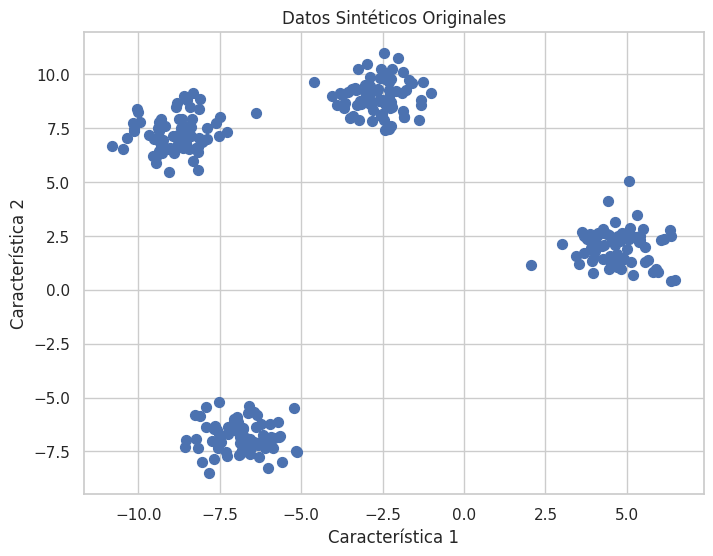

In [54]:
# Ejemplo Ilustrativo de K-Means
from sklearn.datasets import make_blobs

# Generar datos sintéticos para clustering
X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Graficar los datos originales
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50, cmap='viridis')
plt.title("Datos Sintéticos Originales")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

In [55]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # n_init='auto' en versiones más nuevas
kmeans.fit(X_blobs)
y_kmeans = kmeans.predict(X_blobs)
centers = kmeans.cluster_centers_

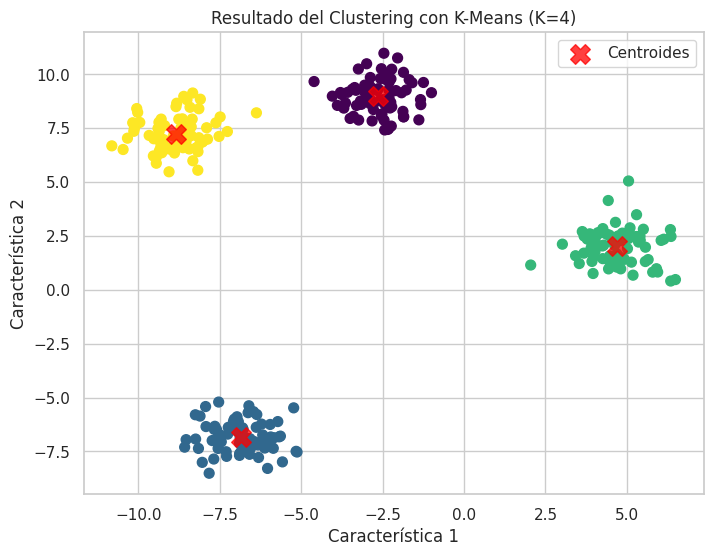

In [56]:
# Graficar los resultados de K-Means
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroides')
plt.title("Resultado del Clustering con K-Means (K=4)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

In [57]:
# Método del Codo para estimar K
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_blobs)
    inertia.append(kmeans_elbow.inertia_)

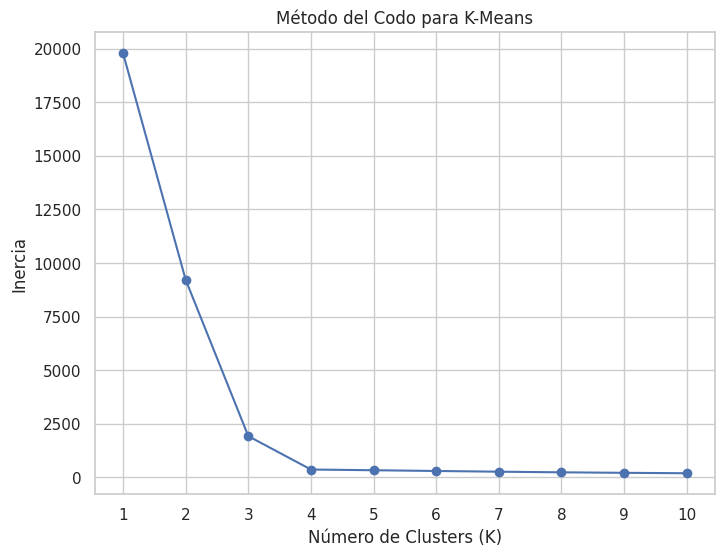

El 'codo' en la gráfica sugiere un buen valor de K (en este caso, K=4 es evidente).


In [58]:
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True)
plt.show()
print("El 'codo' en la gráfica sugiere un buen valor de K (en este caso, K=4 es evidente).")

### 1.2. Clustering Jerárquico (Aglomerativo)

**Concepto:**
El clustering aglomerativo es un enfoque jerárquico "bottom-up".
1.  **Inicio:** Cada punto de datos comienza en su propio cluster.
2.  **Fusión:** En cada paso, los dos clusters más cercanos se fusionan en uno solo. La "cercanía" se define mediante un criterio de enlace (linkage):
    *   **Ward:** Minimiza la varianza dentro de cada cluster (tiende a crear clusters de tamaño similar).
    *   **Complete (Máximo):** La distancia entre clusters es la distancia máxima entre sus puntos.
    *   **Average:** La distancia entre clusters es la distancia promedio entre todos los pares de puntos (uno de cada cluster).
    *   **Single (Mínimo):** La distancia entre clusters es la distancia mínima entre sus puntos (sensible a outliers).
3.  **Fin:** El proceso continúa hasta que todos los puntos están en un solo cluster.

**Dendrograma:**
El resultado se visualiza comúnmente como un dendrograma, un diagrama de árbol que muestra la secuencia de fusiones. La altura de cada fusión representa la distancia a la que se fusionaron los clusters. Cortar el dendrograma a una cierta altura define un número específico de clusters.

**Ventajas:**
*   No requiere especificar el número de clusters de antemano (se puede decidir viendo el dendrograma).
*   Produce una jerarquía de clusters, útil para entender la estructura de los datos.
*   El dendrograma es una visualización informativa.

**Desventajas:**
*   Computacionalmente caro, especialmente para datasets grandes (O(n^2) o O(n^3) dependiendo de la implementación).
*   Las decisiones de fusión son finales (no se pueden deshacer).
*   Sensible a la elección del criterio de enlace y la métrica de distancia.

In [59]:
# Ejemplo Ilustrativo de Clustering Jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

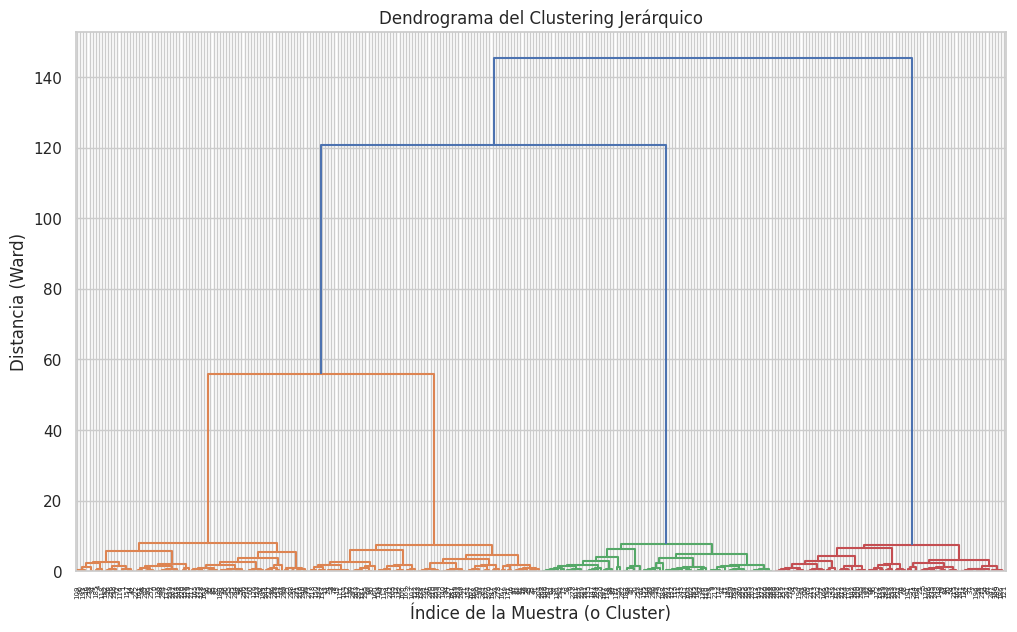

El dendrograma muestra cómo se fusionan los clusters. Cortar en diferentes alturas da diferentes números de clusters.


In [60]:
# Usaremos los mismos datos sintéticos X_blobs

# Calcular la matriz de enlace usando el método 'ward'
linked = linkage(X_blobs, method='ward')

# Dibujar el dendrograma
plt.figure(figsize=(12, 7))
dendrogram(linked,
            orientation='top',
            # labels= # Podrías poner etiquetas aquí si tuvieras pocas muestras
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Dendrograma del Clustering Jerárquico')
plt.xlabel('Índice de la Muestra (o Cluster)')
plt.ylabel('Distancia (Ward)')
plt.show()

print("El dendrograma muestra cómo se fusionan los clusters. Cortar en diferentes alturas da diferentes números de clusters.")

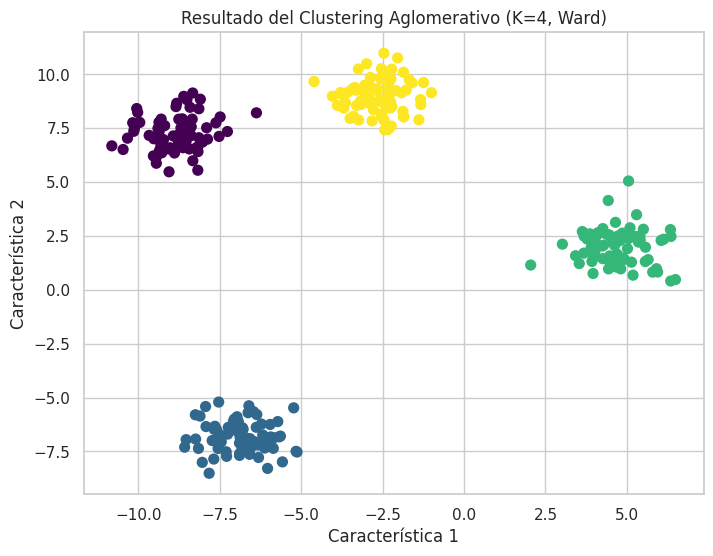

In [61]:
# Aplicar AgglomerativeClustering especificando el número de clusters
# (Puedes elegir n_clusters basado en el dendrograma, por ejemplo, cortando donde hay mayor distancia vertical sin cruzar líneas)
agg_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg_clustering.fit_predict(X_blobs)

# Graficar los resultados
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_agg, s=50, cmap='viridis')
plt.title("Resultado del Clustering Aglomerativo (K=4, Ward)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

### 1.3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Concepto:**
DBSCAN agrupa puntos que están densamente empaquetados, marcando como ruido los puntos que se encuentran solos en regiones de baja densidad. Se basa en dos parámetros:
1.  **`eps` (epsilon):** La distancia máxima entre dos muestras para que una se considere vecina de la otra.
2.  **`min_samples`:** El número de muestras (o peso total) en una vecindad para que un punto sea considerado como un punto *núcleo* (core point).

El algoritmo funciona así:
1.  Se elige un punto arbitrario no visitado.
2.  Si el punto es un *punto núcleo* (tiene al menos `min_samples` vecinos dentro de la distancia `eps`), se inicia un nuevo cluster. Todos los puntos densamente alcanzables desde este punto se añaden al cluster.
3.  Si el punto no es núcleo, se marca temporalmente como ruido (podría ser añadido a un cluster más tarde si es alcanzado por otro punto núcleo).
4.  Se repite el proceso hasta que todos los puntos han sido visitados.

**Ventajas:**
*   No requiere especificar el número de clusters.
*   Puede encontrar clusters de formas arbitrarias.
*   Robusto frente a outliers (los identifica como ruido).

**Desventajas:**
*   No funciona bien con clusters de densidades variables.
*   Sensible a los parámetros `eps` y `min_samples`. Encontrar buenos valores puede ser difícil.
*   Puede tener problemas con datos de muy alta dimensionalidad (la "maldición de la dimensionalidad").

In [62]:
# Ejemplo Ilustrativo de DBSCAN
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [63]:
# Generar datos con forma no esférica (lunas)
X_moons, y_moons_true = make_moons(n_samples=250, noise=0.1, random_state=42)

# Escalar los datos (aunque DBSCAN es menos sensible a la escala que K-Means, sigue siendo buena práctica)
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

In [64]:
# Aplicar DBSCAN
# Encontrar buenos eps y min_samples puede requerir experimentación
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons_scaled)

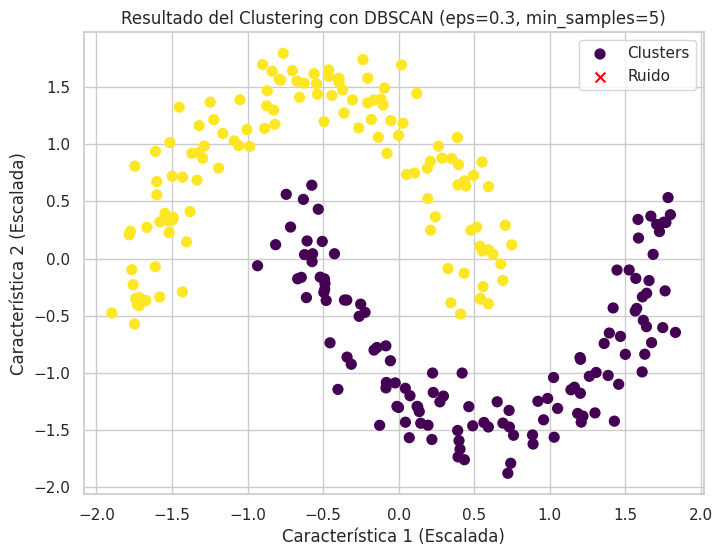

Número de clusters encontrados: 2
Número de puntos de ruido encontrados: 0


In [65]:
# Graficar los resultados
plt.figure(figsize=(8, 6))

# Los puntos marcados como -1 son ruido
noise_mask = y_dbscan == -1
clusters_mask = y_dbscan != -1

plt.scatter(X_moons_scaled[clusters_mask, 0], X_moons_scaled[clusters_mask, 1], c=y_dbscan[clusters_mask], s=50, cmap='viridis', label='Clusters')
plt.scatter(X_moons_scaled[noise_mask, 0], X_moons_scaled[noise_mask, 1], c='red', s=50, marker='x', label='Ruido')

plt.title(f"Resultado del Clustering con DBSCAN (eps=0.3, min_samples=5)")
plt.xlabel("Característica 1 (Escalada)")
plt.ylabel("Característica 2 (Escalada)")
plt.legend()
plt.show()

print(f"Número de clusters encontrados: {len(set(y_dbscan[y_dbscan != -1]))}")
print(f"Número de puntos de ruido encontrados: {np.sum(y_dbscan == -1)}")

## 2. Reducción de la Dimensionalidad

Cuando trabajamos con datasets que tienen muchas características (alta dimensionalidad), podemos enfrentar problemas como la "maldición de la dimensionalidad", mayor coste computacional y dificultad para visualizar. La reducción de dimensionalidad busca reducir el número de características manteniendo la mayor cantidad de información relevante posible.

---

### 2.1. Análisis de Componentes Principales (PCA)

**Concepto:**
PCA es una técnica lineal que transforma los datos a un nuevo sistema de coordenadas donde las nuevas características (componentes principales) capturan la máxima varianza posible de los datos y no están correlacionadas entre sí.
1.  Estandariza los datos (media 0, varianza 1).
2.  Calcula la matriz de covarianza.
3.  Calcula los eigenvectores y eigenvalores de la matriz de covarianza.
4.  Los eigenvectores (ordenados por sus eigenvalores correspondientes de mayor a menor) definen las direcciones de los nuevos ejes (componentes principales). El eigenvalor indica la cantidad de varianza explicada por ese componente.
5.  Se proyectan los datos originales sobre los primeros `k` componentes principales para reducir la dimensionalidad a `k`.

**¿Cuántos componentes elegir?** Se suele mirar la "varianza explicada acumulada". Por ejemplo, elegir suficientes componentes para explicar el 90% o 95% de la varianza total.

**Ventajas:**
*   Efectivo para reducir dimensiones eliminando redundancia (correlación).
*   No requiere parámetros complejos (solo el número de componentes deseado).
*   Útil para visualización (reduciendo a 2 o 3D) y como preprocesamiento para otros algoritmos.

**Desventajas:**
*   Asume linealidad en las relaciones entre características.
*   Los componentes principales resultantes pueden no ser fácilmente interpretables en términos de las características originales.
*   Sensible a la escala de los datos (¡importante escalar!).

In [66]:
# Ejemplo Ilustrativo de PCA
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

# Escalar los datos
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)


In [67]:
# Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

In [68]:
# Varianza explicada por cada componente
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_)}")

Varianza explicada por componente: [0.72962445 0.22850762]
Varianza explicada acumulada: 0.9581320720000166


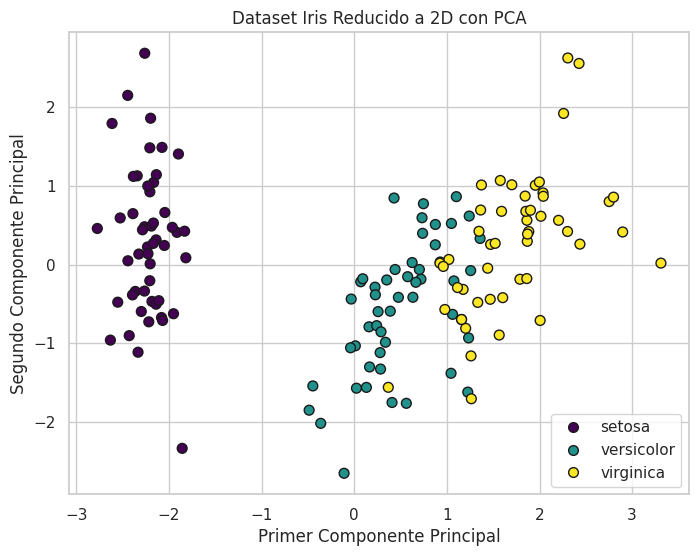

In [69]:
# Graficar los datos reducidos a 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', edgecolor='k', s=50)
plt.title('Dataset Iris Reducido a 2D con PCA')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')

# Get unique labels and handles for the legend
unique_labels = np.unique(iris.target_names) # Ensure unique labels
handles = [plt.Line2D([], [], color=scatter.cmap(scatter.norm(i)), marker='o', linestyle='', markersize=7, markeredgecolor='k') for i in np.unique(y_iris)]

plt.legend(handles, unique_labels) # Pass handles and labels to legend
plt.grid(True)
plt.show()

### 3.2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Concepto:**
t-SNE es una técnica no lineal utilizada principalmente para la **visualización** de datos de alta dimensionalidad en espacios de baja dimensión (generalmente 2D o 3D). Funciona modelando las similitudes entre puntos de datos en el espacio original y tratando de encontrar una representación de baja dimensión que preserve esas similitudes locales.

**Parámetros Clave:**
*   `n_components`: Dimensión del espacio embebido (usualmente 2 o 3).
*   `perplexity`: Relacionado con el número de vecinos cercanos que cada punto considera. Valores típicos entre 5 y 50. Afecta el balance entre aspectos locales y globales.
*   `learning_rate`: Controla cuánto se ajustan los puntos en cada iteración.
*   `n_iter`: Número de iteraciones.

**Ventajas:**
*   Excelente para revelar estructuras locales y clústeres en los datos para visualización.
*   Puede manejar relaciones no lineales.

**Desventajas:**
*   **No es una técnica de reducción de dimensionalidad general:** Está optimizada para visualización, no para usar como entrada a otros algoritmos. Las distancias entre clusters en el mapa t-SNE no siempre son significativas.
*   Computacionalmente intensivo, especialmente para datasets grandes.
*   Es estocástico (resultados pueden variar ligeramente entre ejecuciones).
*   Los resultados dependen bastante de los parámetros (especialmente `perplexity`).

In [70]:
# Ejemplo Ilustrativo de TSNE
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

# Escalar los datos
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [71]:
# Aplicar PCA para reducir a 2 componentes
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_iris_scaled)

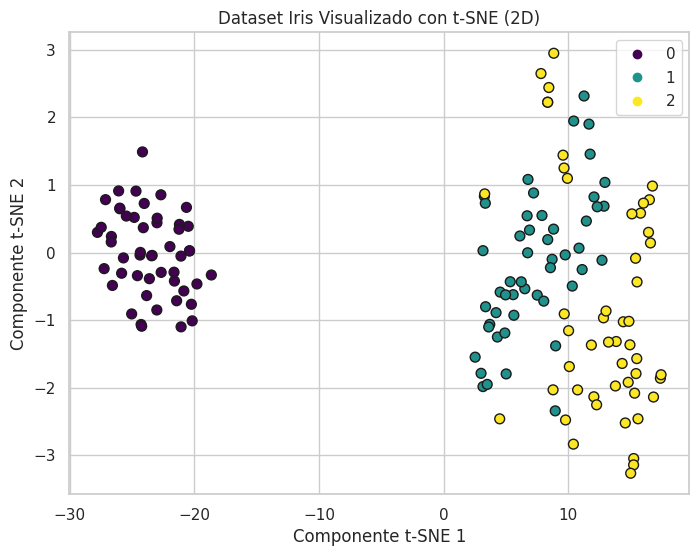

t-SNE a menudo separa mejor los clusters para visualización que PCA, pero las distancias relativas entre clusters no son significativas.


In [72]:
# Graficar los resultados de t-SNE
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_iris, cmap='viridis', edgecolor='k', s=50)
plt.title('Dataset Iris Visualizado con t-SNE (2D)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')

# Fix: Use legend_elements() directly or ensure handles and labels are compatible
handles, labels = scatter.legend_elements()
plt.legend(handles, labels)  # Pass handles and labels to legend

plt.grid(True)
plt.show()
print("t-SNE a menudo separa mejor los clusters para visualización que PCA, pero las distancias relativas entre clusters no son significativas.")

## 4. Ejercicio Práctico: Segmentación de Clientes con K-Means

**Contexto:** Eres el manager de un centro comercial y necesitas segmentar a tus 200 clientes para crear estrategias de marketing diferenciadas.

**Tu objetivo:** Usar K-Means para agrupar clientes similares y luego... clasificarlos tú mism@.

---

### Paso 1: Cargar los Datos

Vamos a usar el dataset **Mall Customers** que contiene información de 200 clientes del shopping.

| Columna | Descripción |
|--------|----------|
| CustomerID | ID único del cliente |
| Genre | Género (Male/Female) |
| Age | Edad del cliente |
| Annual Income (k$) | Ingreso anual en miles de dólares |
| Spending Score (1-100) | Score de gasto calculado por el mall |


In [73]:
# Cargar el dataset desde URL pública
url = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/Mall_Customers.csv'
df = pd.read_csv(url)

# Verificamos que se cargó correctamente
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


### Paso 2: Exploración de los Datos

Antes de aplicar clustering, necesitamos entender nuestra materia prima. Vamos a ver:
- ¿Cuántos clientes tenemos?
- ¿Qué edades tienen?
- ¿Cuánto ganan?
- ¿Cómo gastan?

Vemos la información básica y las estadísticas descriptivas.

In [74]:
# Información básica del dataset
print(f"Cantidad de clientes: {df.shape[0]}")
print(f"Columnas: {df.columns.tolist()}")
print()
# Estadísticas descriptivas
df.describe()

Cantidad de clientes: 200
Columnas: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']



,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60560.000000,50.200000
std,57.879185,13.969007,26264.721165,25.823522
min,1.000000,18.000000,15000.000000,1.000000
25%,50.750000,28.750000,41500.000000,34.750000
50%,100.500000,36.000000,61500.000000,50.000000
75%,150.250000,49.000000,78000.000000,73.000000
max,200.000000,70.000000,137000.000000,99.000000


### Paso 3: Visualización de Distribución

Vamos a graficar la distribución de cada variable numérica para entender mejor a nuestros clientes.

Esto nos ayuda a:
- Ver si hay valores atípicos (outliers)
- Entender el rango de cada variable
- Identificar posibles patrones

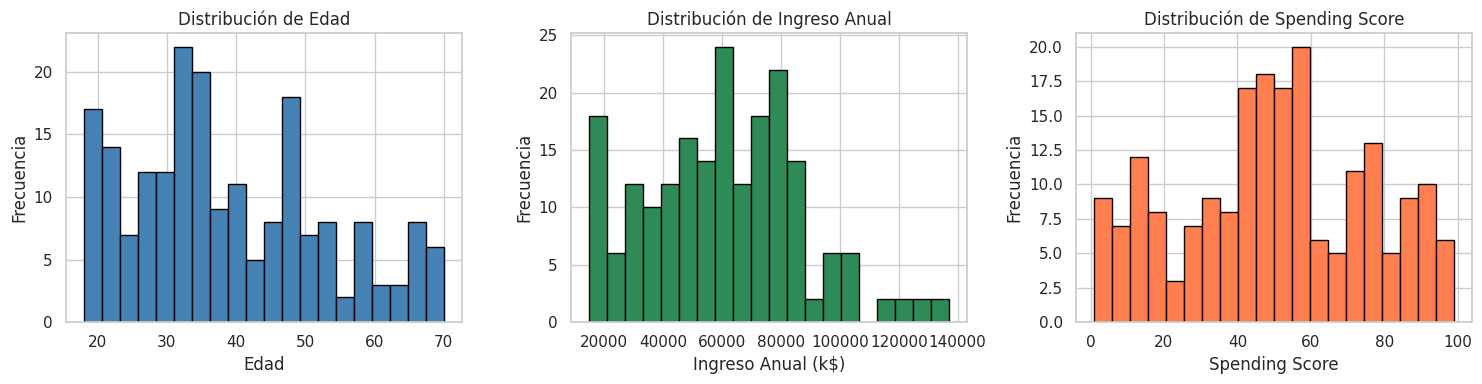

In [75]:
# Distribución de las variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Annual Income
axes[1].hist(df['AnnualIncome'], bins=20, color='seagreen', edgecolor='black')
axes[1].set_title('Distribución de Ingreso Anual')
axes[1].set_xlabel('Ingreso Anual (k$)')
axes[1].set_ylabel('Frecuencia')

# Spending Score
axes[2].hist(df['SpendingScore'], bins=20, color='coral', edgecolor='black')
axes[2].set_title('Distribución de Spending Score')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Paso 4: Selección de Features para Clustering

Para este ejercicio, vamos a usar **dos variables**:
- **Annual Income (k$)** - Ingreso anual
- **Spending Score (1-100)** - Score de gasto

¿Por qué solo dos?
1. Son las más relevantes para segmentación de clientes
2. Permiten visualizar en 2D fácilmente
3. El Spending Score ya es un indicador de comportamiento que calculó el mall

> **Nota:** En un caso real, podrías usar más variables (Age, Genre, etc.), pero para aprender, mejor empezar simple.

In [76]:
# Seleccionamos las features para clustering
X = df[['AnnualIncome', 'SpendingScore']].values

# Escalar los datos (importante para K-Means)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Forma de los datos: {X_scaled.shape}")
print(f"Media (después de escalar): {X_scaled.mean(axis=0).round(2)}")
print(f"Desvío estándar (después de escalar): {X_scaled.std(axis=0).round(2)}")

Forma de los datos: (200, 2)
Media (después de escalar): [-0. -0.]
Desvío estándar (después de escalar): [1. 1.]


### Paso 5: Método del Codo

Antes de aplicar K-Means, necesitamos decidir **cuántos clusters (K)** usar.

El **Método del Codo** funciona así:
1. Ejecutamos K-Means para diferentes valores de K (1, 2, 3, ...)
2. Para cada K, medimos la **inercia** (suma de distancias al centroide más cercano)
3. Graficamos K vs Inercia
4. El "codo" = donde agregar más clusters ya no reduce mucho la inercia

Ejecutá la siguiente celda para encontrar el K óptimo.

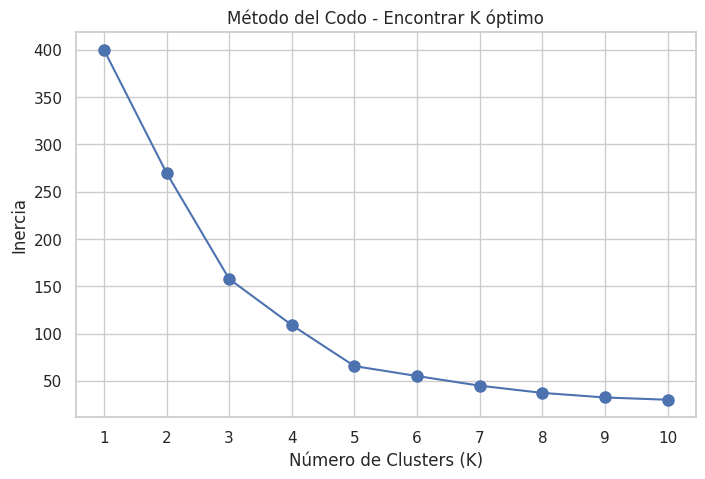


📊 ¿Dónde está el "codo"? Observá el gráfico y decidí cuántos clusters usar.


In [77]:
# Método del Codo
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo - Encontrar K óptimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print('\n📊 ¿Dónde está el "codo"? Observá el gráfico y decidí cuántos clusters usar.')

### Paso 6: Decision - ¿Cuántos Clusters?

**Tu turno:**

Mirando el gráfico del codo, respondé:
- ¿Dónde parece estar el "codo"?
- ¿Qué K elegís y por qué?

---

**Pista:** El punto donde la curva empieza a aplanarse suele ser un buen indicador.

---

En el próximo paso, ejecutamos K-Means con el K que elijas. Ejecutá la siguiente celda con tu K elegido.

In [78]:
# Elegí tu K aquí (cambia el valor)
K = 5  # <-- CAMBIÁ ESTE VALOR si elegís otro K

# Aplicar K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Obtener las etiquetas de cluster
labels = kmeans.labels_

# Agregar los clusters al DataFrame original
df['Cluster'] = labels

print(f"✅ K-Meansapplied with K={K}")
print(f"\nDistribución de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Meansapplied with K=5

Distribución de clientes por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### Paso 7: Visualizar los Clusters

Ahora vamos a ver cómo quedaron nuestros clusters en un gráfico 2D.

Cada punto representa un cliente, y su color indica a qué cluster pertenece.
Las 'X' marcan los centroides de cada cluster.

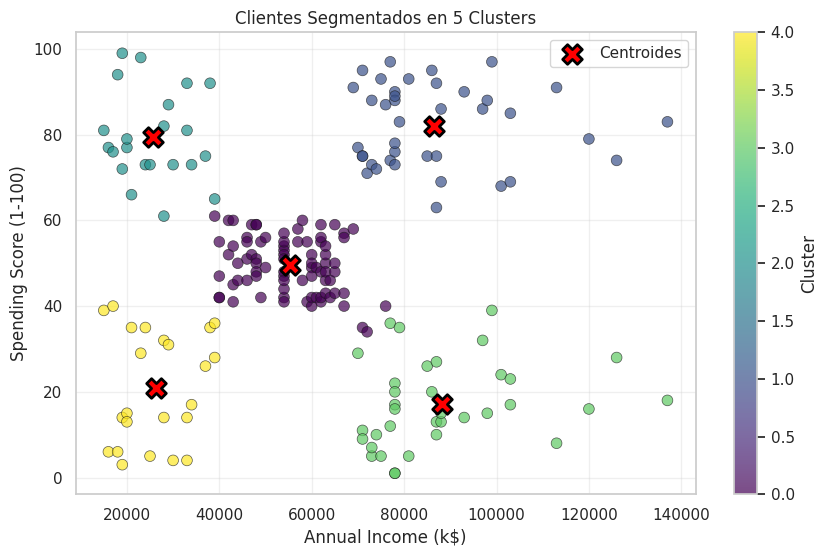

In [80]:
# Visualizar los clusters
plt.figure(figsize=(10, 6))

# Scatter plot con colores por cluster
scatter = plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)

# Centroides (en datos originales, no escalados)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=200,
    edgecolor='black',
    linewidth=2,
    label='Centroides'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Clientes Segmentados en {K} Clusters')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Paso 8: Analizar cada Cluster

Llego la parte más interesante: **investigamos qué tiene cada cluster**.

Para cada cluster, vamos a ver:
- ¿Cuántos clientes tiene?
- ¿Cuál es la edad promedio?
- ¿Cuál es el ingreso promedio?
¿Cuál es el spending score promedio?

Esto nos va a dar pistas para **clasificar** cada grupo.

In [81]:
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster').agg({
    'Cluster': 'count',
    'Age': 'mean',
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean'
}).rename(columns={
    'Cluster': 'Cantidad',
    'Age': 'Edad Promedio',
    'AnnualIncome': 'Ingreso Promedio (k$)',
    'SpendingScore': 'Spending Score Promedio'
})

cluster_stats = cluster_stats.round(1)
print("📊 Estadísticas por Cluster:\n")
print(cluster_stats)
print()
# También ver rango de edad y de income
print("\n📈 Rangos por Cluster:")
for c in range(K):
    cluster_data = df[df['Cluster'] == c]
    print(f"\nCluster {c}:")
    print(f"  Edad: {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
    print(f"  Ingreso: {cluster_data['AnnualIncome'].min()} - {cluster_data['AnnualIncome'].max()} k$")
    print(f"  Spending: {cluster_data['SpendingScore'].min()} - {cluster_data['SpendingScore'].max()}")

📊 Estadísticas por Cluster:

         Cantidad  Edad Promedio  Ingreso Promedio (k$)  \
Cluster                                                   
0              81           42.7                55296.3   
1              39           32.7                86538.5   
2              22           25.3                25727.3   
3              35           41.1                88200.0   
4              23           45.2                26304.3   

         Spending Score Promedio  
Cluster                           
0                           49.5  
1                           82.1  
2                           79.4  
3                           17.1  
4                           20.9  


📈 Rangos por Cluster:

Cluster 0:
  Edad: 18 - 70
  Ingreso: 39000 - 76000 k$
  Spending: 34 - 61

Cluster 1:
  Edad: 27 - 40
  Ingreso: 69000 - 137000 k$
  Spending: 63 - 97

Cluster 2:
  Edad: 18 - 35
  Ingreso: 15000 - 39000 k$
  Spending: 61 - 99

Cluster 3:
  Edad: 19 - 59
  Ingreso: 70000 - 137000 k$
  

### Paso 9: Clasificar los Clusters

**¡Ahora viene lo más interesante!**

Basándote en los datos de cada cluster, assignale un **nombre** que lo defina.

---

**Ejemplos de clasificación:**

| Cluster | Característica | Nombre Sugerido |
|--------|-------------|----------------|
| 0 | Bajo ingreso, Bajo gasto | "Conservadores" |
| 1 | Alto ingreso, Alto gasto | "VIPs" |
| 2 | Medio ingreso, Medio gasto | "Clase Media" |

---

**Tu turno:** Creá una tabla con tus clasificaciones y explicá por qué elegiste cada nombre.

> 💡 **Tip:** Fijate en las combinaciones:
- Alto/Bajo Income + Alto/Bajo Spending = 4 combinaciones possíveis

In [ ]:
# TABLA DE CLASIFICACIÓN - COMPLETÁ CON TUS NOMBRES
# Ejemplo de estructura:
# classificacion = {
#     0: ('Nombre', 'Descripción'),
#     1: ('Nombre', 'Descripción'),
#     ...
# }

#Completá con tus clasificaciones:
clasificacion = {
    0: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    1: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    2: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    3: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    4: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
}

print("🎯 Mi clasificación de clusters:\n")
for cluster_id, (nombre, desc) in clasificacion.items():
    print(f"Cluster {cluster_id}: {nombre}")
    print(f"   → {desc}\n")

### Paso 10: Reflexión Final

---

**¿Qué aprendimos?**

1. ✅ Cargar y explorar datos reales
2. ✅ Aplicar el Método del Codo para elegir K
3. ✅ Usar K-Means para clustering
4. ✅ Analizar y caracterizar cada cluster
5. ✅ **Clasificar** basándonos en los datos (no en intuición)

---

**Para pensar:**

- ¿El K que elegiste fue el óptimo?
- ¿Cómo cambiarían las clasificaciones si elegieras otro K?
- ¿Qué estrategias de marketing propondrías para cada segmento?

---

> 🎓 **Conclusión:** El clustering nos da grupos, pero la clasificación (poner nombre) la Hacemos NOSOTROS. Por eso es importante investigar los datos antes de concluir.